# Algorithmic Trading: Build a Momentum Strategy in Python
Digital Hub Insights LLC.

December 2025

Version: 4.0

Taught by: Cordell L. Tanny, CFA, FRM, FDP

Learn more about us: [digitalhub-labs.com](https://)


---



## Momentum Strategy Backtest Part 2: Data & Signal Generation

Welcome to the second notebook in our course on building an algorithmic momentum strategy.

In Notebook 1, we did the "academic" work. We proved that the momentum anomaly, which is the tendency for past winners to keep winning, is a real and robust phenomenon within our universe of ETFs. Through decile analysis and heatmaps, we confirmed that the top-performing ETFs consistently outperformed the bottom-performing ones across various timeframes. That research gives us the confidence to build a strategy on this principle.

Now, it is time to move from theory to practice. This notebook is where we build the core engine of our trading strategy. We will take the concepts we validated and turn them into a concrete, actionable trading signal.

Notebook 2 Goals:

- Set Up Our Workshop: We will import the necessary Python libraries and set up our API key for data access.

- Choose Our Players: We will formally list the equity, fixed income, and commodity ETFs that our strategy will choose from.

- Gather and Resample Price Data: We will download daily historical prices for all ETFs and convert them into a monthly series, which is the frequency at which our strategy makes decisions.

- Calculate Momentum and Rank: This is the heart of the notebook. We will implement the logic to calculate each ETF's performance over our chosen lookback period (12 months) and rank them from best to worst.

- Generate the Signal: From the rankings, we will select the "top 10" ETFs each month. This list of top performers is our trading signal.

- Run a Simple Backtest: To get an initial feel for our strategy's performance, we will run a simplified simulation comparing the returns of our "top 10" portfolio against a buy-and-hold investment in the S&P 500 (SPY).

By the end of this notebook, you will have the fundamental logic for a momentum strategy coded and will have seen its preliminary performance. Let us begin building.

## Setting Up Our Environment: Imports and API Key

Every Python project, especially in data science, starts with setting up the "workshop". This cell imports all the essential libraries and tools we will need for our analysis. Think of it as gathering your ingredients before you start cooking.

- `!pip install -q pandas_market_calendars`: This command quietly `(-q)` installs a specialized library that knows the official trading days for various stock exchanges. We will use this later to ensure our strategy only attempts to trade on days the market is actually open, thus avoiding weekends or holidays.

- `pandas` & `numpy`: These are the cornerstones of data analysis in Python. Pandas gives us the powerful DataFrame, which is like a spreadsheet for handling our financial time-series data. Numpy provides the high-performance numerical engine that powers pandas.

- `matplotlib.pyplot` & `seaborn`: These are our visualization libraries. Matplotlib is the foundational plotting tool, while Seaborn builds on top of it to create more statistically informative and aesthetically pleasing charts. sns.set_theme() applies Seaborn's default visual style to all our plots.

- `datetime`, `timedelta`, `pandas_market_calendars`: These libraries are all about handling time. datetime and timedelta are standard Python tools for working with dates and time differences, and mcal is the alias for the market calendar library we just installed.

- `functions as fn` & `requests`: `requests` is the standard library for making HTTP requests to APIs over the internet. It is the engine that runs in the background of our custom `functions.py` file (fn), which contains helper functions we have written to keep this notebook clean and focused. For instance, `fn.get_bulk_prices` uses requests to talk to our data provider.

- `google.colab import userdata`: This is a secure way to handle sensitive information in Google Colab. Instead of pasting your secret API key directly into the code, which is bad practice, `userdata` allows you to store it securely in Colab's "Secrets" manager.

- `fmp_api_key = userdata.get('FMP')`: This line retrieves our secret API key for Financial Modeling Prep (FMP), our data provider, and stores it in a variable. To make this work, you must add your own FMP key to the Colab Secrets Manager with the name FMP.

With our tools ready, we can now move on to defining the universe of assets our strategy will trade.

In [1]:
# !pip install -q pandas_market_calendars
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
from momentum_trading.core import functions as fn
# from google.colab import userdata
import pandas_market_calendars as mcal
import requests

sns.set_theme()

# API Keys - set to None if not available
try:
    fmp_api_key = userdata.get('FMP_API_KEY')
except:
    fmp_api_key = None

try:
    eodhd_api_key = userdata.get('EOD')
except:
    eodhd_api_key = None

## Defining Our Asset Universe

Before we can analyze momentum, we need to decide which assets our strategy is allowed to trade. This collection of potential investments is called the "investment universe". A well-chosen universe is a critical first step in strategy design. A broad and diverse universe allows the strategy to find performance trends wherever they may appear in the market.

This code block defines our universe by creating Python dictionaries for three distinct categories of Exchange Traded Funds (ETFs). We use dictionaries here to store the ticker symbol (e.g., "QQQ") as the "key" and the ETF's full name as the "value" for easy reference.

- Equity ETFs: This is our largest group. It covers a wide range of the stock market, including broad market indexes (like `VTI`), specific market segments (like `IWM` for small-cap stocks), and individual sectors (like `XLE` for energy).

- Fixed Income ETFs: This group provides exposure to bonds. It includes ETFs that track government bonds of different maturities (like `TLT` for long-term treasuries) and corporate bonds of varying credit quality (like `LQD` for investment-grade and `HYG` for high-yield).

- Alternative and Commodity ETFs: This category includes assets that behave differently from traditional stocks and bonds. It gives our strategy the ability to find momentum in areas like precious metals (`GLD` for Gold), energy (`USO` for Oil), and agriculture (`DBA`).

By including different asset classes, we are not just building a stock-picking strategy. We are building a dynamic asset allocation strategy that can rotate into bonds or commodities if they are outperforming stocks.

Finally, the last line of code extracts all the ticker symbols from these dictionaries and combines them into a single list called tickers. This master list is what we will use in the next step to download all the necessary price data.

In [2]:
equity_etfs = {
    "QQQ": "Invesco QQQ Trust",
    "VTI": "Vanguard Total Stock Market ETF",
    "VYM": "Vanguard High Dividend Yield ETF",
    "IWM": "iShares Russell 2000 ETF",
    "SMDV": "ProShares Russell 2000 Dividend Growers",
    "SPYG": "SPDR Portfolio S&P 500 Growth ETF",
    "IWF": "iShares Russell 1000 Growth ETF",
    "VO": "Vanguard Mid-Cap ETF",
    "VBR": "Vanguard Small-Cap Value ETF",
    "VOE": "Vanguard Mid-Cap Value ETF",
    "SPGP": "Invesco S&P 500 GARP ETF",
    "REGL": "S&P MidCap 400 Dividend Aristocrats ETF",
    "IWV": "iShares Russell 3000 ETF",
    "XLF": "Financial Select Sector SPDR Fund",
    "XLE": "Energy Select Sector SPDR Fund",
    "XLK": "Technology Select Sector SPDR Fund",
    "XLV": "Health Care Select Sector SPDR Fund",
    "XLY": "Consumer Discretionary Select Sector SPDR Fund",
    "XLI": "Industrial Select Sector SPDR Fund",
    "XLP": "Consumer Staples Select Sector SPDR Fund",
    "XLU": "Utilities Select Sector SPDR Fund",
    "XLC": "Communication Services Select Sector SPDR Fund",
    "SOXX": "iShares Semiconductor ETF",
    "MOAT": "VanEck Morningstar Wide Moat ETF",
    "ARKK": "ARK Innovation ETF",
    "ARKG": "ARK Genomic Revolution ETF",
    "ARKW": "ARK Next Generation Internet ETF",
    "SDY": "SPDR S&P Dividend ETF",
    "USMV": "iShares Edge MSCI Min Vol USA ETF",
    "HDV": "iShares Core High Dividend ETF",
    "DIA": "SPDR Dow Jones Industrial Average ETF Trust",
    "FDN": "First Trust Dow Jones Internet Index Fund",
    "VIG": "Vanguard Dividend Appreciation ETF",
    "FPX": "First Trust US Equity Opportunities ETF",
    "ITB": "iShares U.S. Home Construction ETF",
    "ITA": "iShares U.S. Aerospace & Defense ETF",
    "DES": "WisdomTree U.S. SmallCap Dividend Fund",
    "XMLV": "Invesco S&P MidCap Low Volatility ETF",
    "SPY": "SPDR S&P 500 ETF Trust",
    "QTUM": "Defiance Quantum ETF",
}

# Fixed Income ETFs - Treasury, Corporate, and High Yield bonds
fixed_income_etfs = {
    "TLT": "iShares 20+ Year Treasury Bond ETF",
    "IEF": "iShares 7-10 Year Treasury Bond ETF",
    "SHY": "iShares 1-3 Year Treasury Bond ETF",
    "BIL": "SPDR Bloomberg 1-3 Month T-Bill ETF",
    "AGG": "iShares Core U.S. Aggregate Bond ETF",
    "LQD": "iShares iBoxx $ Investment Grade Corporate Bond ETF",
    "HYG": "iShares iBoxx $ High Yield Corporate Bond ETF",
    "MBB": "iShares MBS ETF",
    "PFF": "iShares Preferred and Income Securities ETF",
}

# Alternative/Commodity ETFs - Gold, Silver, Commodities, etc.
other_etfs = {
    "GLD": "SPDR Gold Shares",
    "SLV": "iShares Silver Trust",
    "DBC": "Invesco DB Commodity Index Tracking Fund",
    "USO": "United States Oil Fund",
    "PICK": "ishares MSCI Global Metals & Mining Producers ETF",
    "UUP": "Invesco DB US Dollar Index Bullish Fund",
    "GDX": "VanEck Vectors Gold Miners ETF",
    "GDXJ": "VanEck Vectors Junior Gold Miners ETF",
    "DBA": "Invesco DB Agriculture Fund",
}

# Combine all tickers for data loading
tickers = list(equity_etfs.keys()) + list(fixed_income_etfs.keys()) + list(other_etfs.keys())

## Defining Strategy Parameters and Fetching Data

This code cell is foundational. It performs two critical tasks: first, it defines the core rules of our momentum strategy, and second, it downloads the raw historical price data that we will use for our analysis.

Strategy Parameters

At the top of the cell, we define two key variables that control the logic of our strategy. These are intentionally placed here so you can easily change them later to experiment with different momentum styles.

- lookback_period: This is the time window over which we measure an asset's performance. A value of 12 means that to determine an ETF's momentum, we will calculate its total return over the past 12 months. This is our "lookback" window to identify winners.

- holding_period: This determines how long we will hold our selected ETFs before re-evaluating the portfolio. A value of 1 means our strategy will rebalance every month. We will select the top performers, hold them for one month, and then repeat the process.

In [3]:
# ===============================================================
# Strategy Parameters - You can change these!
# ===============================================================
lookback_period = 12  # The number of months to look back to calculate momentum
holding_period = 1   # The number of months to hold the portfolio before rebalancing
# ===============================================================

# Download prices for all ETFs
start_date = '2005-01-01'
end_date = '2025-08-31'

# Use the get_bulk_prices function to retrieve all prices for our ETFs
# Auto-fallback: tries FMP → EODHD → Yahoo Finance
df_prices = fn.get_bulk_prices(
    tickers,
    start_date,
    end_date,
    fmp_api_key=fmp_api_key,
    eodhd_api_key=eodhd_api_key
)

# Resample to monthly
df_prices_monthly = df_prices.resample('ME').last()

df_prices_monthly.tail()

Determining best data source using QQQ...
Data retrieved from yf for QQQ
Using yf for all tickers
Data retrieved from yf for QQQ
Data retrieved from yf for VTI
Data retrieved from yf for VYM
Data retrieved from yf for IWM
Data retrieved from yf for SMDV
Data retrieved from yf for SPYG
Data retrieved from yf for IWF
Data retrieved from yf for VO
Data retrieved from yf for VBR
Data retrieved from yf for VOE
Data retrieved from yf for SPGP
Data retrieved from yf for REGL
Data retrieved from yf for IWV
Data retrieved from yf for XLF
Data retrieved from yf for XLE
Data retrieved from yf for XLK
Data retrieved from yf for XLV
Data retrieved from yf for XLY
Data retrieved from yf for XLI
Data retrieved from yf for XLP
Data retrieved from yf for XLU
Data retrieved from yf for XLC
Data retrieved from yf for SOXX
Data retrieved from yf for MOAT
Data retrieved from yf for ARKK
Data retrieved from yf for ARKG
Data retrieved from yf for ARKW
Data retrieved from yf for SDY
Data retrieved from yf for

,QQQ,VTI,VYM,IWM,SMDV,SPYG,IWF,VO,VBR,VOE,...,PFF,GLD,SLV,DBC,USO,PICK,UUP,GDX,GDXJ,DBA
date,,,,,,,,,,,,,,,,,,,,,
2025-04-30,472.660156,268.859436,120.572235,192.325119,61.117805,81.438148,91.270210,62.865437,175.665222,151.742691,...,28.107618,303.769989,29.600000,19.900236,63.560001,33.681591,26.504795,48.656616,60.017288,25.876766
2025-05-31,516.042358,285.671783,125.050079,202.402313,62.329304,89.075447,99.392189,66.319366,184.449448,157.337891,...,28.317448,303.600006,30.000000,20.200142,67.150002,35.290951,26.543476,50.284798,63.849007,25.770596
2025-06-30,548.995850,300.422089,130.068680,213.571747,63.423183,94.807999,105.753113,68.957817,191.224731,161.157440,...,28.906313,304.829987,32.810001,21.099863,73.110001,36.705261,25.992298,51.684628,66.067886,25.239740
2025-07-31,562.301880,307.301758,130.868744,217.134766,63.093685,98.030594,109.696007,70.475815,194.421478,163.979599,...,29.611298,302.959991,33.320000,21.719025,79.589996,37.466698,26.978613,51.267654,62.773781,24.998442
2025-08-31,567.666077,314.527405,135.795944,232.752548,66.647957,98.955589,110.986229,71.446739,204.747101,169.329956,...,29.965624,318.070007,36.189999,21.486837,74.839996,40.024353,26.466118,62.714520,78.247299,26.803350


### Calculating Monthly Returns

Having prices is good, but for a momentum strategy, what we really care about is performance. The best way to measure and compare performance is by looking at returns, or the percentage change in price over a period. This cell converts our DataFrame of monthly prices into a DataFrame of monthly returns.

- `df_prices_monthly.pct_change()`: This is the pandas method that does all the work for us. It calculates the percentage change from one row to the next. Since our data is already resampled to a monthly frequency, this one command calculates the monthly return for every ETF.

- `fill_method='ffill'`: This argument addresses how to handle missing data points before calculating the change. `ffill` stands for "forward fill", which means if a price is missing for a particular month, pandas will use the price from the previous month to calculate the return. Note: You will see a FutureWarning message in the output. This is pandas telling us that this way of handling missing data inside the pct_change function is being phased out. Modern best practice is to handle missing data explicitly before calculating returns. For our purpose here, the result is still correct.

- `dropna(how='all')`: After calculating returns, the very first row of our DataFrame will be all NaN (Not a Number). This is because there is no prior month's data to calculate a return from. The .`dropna(how='all')` method cleans this up by dropping any row where all values are NaN.

The resulting df_returns DataFrame now shows the monthly percentage growth for each ETF in our universe. Notice the NaN values for ETFs like VYM in the early years. This is expected and correct; it simply means those ETFs were not trading yet, so no return can be calculated.

In [4]:
df_returns = df_prices_monthly.pct_change().ffill().dropna(how='all')
df_returns.head()

,QQQ,VTI,VYM,IWM,SMDV,SPYG,IWF,VO,VBR,VOE,...,PFF,GLD,SLV,DBC,USO,PICK,UUP,GDX,GDXJ,DBA
date,,,,,,,,,,,,,,,,,,,,,
2005-02-28,-0.004813,0.020852,NaN,0.016420,NaN,-0.000213,0.012005,0.037156,0.024034,NaN,...,NaN,0.031028,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2005-03-31,-0.017463,-0.018720,NaN,-0.028348,NaN,-0.022317,-0.021673,-0.011423,-0.021594,NaN,...,NaN,-0.016311,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2005-04-30,-0.043478,-0.022027,NaN,-0.056569,NaN,-0.029899,-0.018349,-0.036764,-0.050293,NaN,...,NaN,0.012377,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2005-05-31,0.088622,0.038814,NaN,0.064647,NaN,0.059842,0.049990,0.053980,0.072792,NaN,...,NaN,-0.039216,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2005-06-30,-0.033246,0.007582,NaN,0.040763,NaN,-0.014814,-0.004748,0.030005,0.035583,NaN,...,NaN,0.042977,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Establishing a Benchmark: The Buy-and-Hold Strategy

A trading strategy is only useful if it can outperform a simple, passive alternative. The most common benchmark for US stock strategies is the S&P 500 index. If our complex momentum strategy cannot generate better returns than simply buying and holding the S&P 500, then it is not adding any value.

This cell downloads and prepares the historical data for the SPDR S&P 500 ETF Trust (ticker: SPY), which is the fund that tracks this benchmark index.

In [5]:
# Buy and hold strategy
df_spy = fn.get_stock_prices(
    'SPY', start_date, end_date,
    fmp_api_key=fmp_api_key,
    eodhd_api_key=eodhd_api_key
)

# Get adjusted close column (name varies by data source)
if 'adjClose' in df_spy.columns:
    df_spy_prices = df_spy['adjClose'].to_frame(name='SPY')
elif 'adjusted_close' in df_spy.columns:
    df_spy_prices = df_spy['adjusted_close'].to_frame(name='SPY')
else:
    df_spy_prices = df_spy['Adj Close'].to_frame(name='SPY')
# Resample SPY prices to monthly
df_spy_prices_monthly = df_spy_prices.resample('ME').last()
# Calculate monthly returns for SPY
df_spy_returns = df_spy_prices_monthly.pct_change(fill_method=None).dropna()

Data retrieved from Yahoo Finance for SPY


## Calculating Momentum Scores

With our monthly price data in hand, we can now calculate the momentum of each ETF. Momentum, in our case, is simply the performance or return over a specific lookback period. This function, `calculate_period_returns`, is a helper tool designed to do exactly that.

A function is a reusable block of code that performs a specific task. We create this function so that we do not have to write the same lines of code repeatedly. It makes our notebook cleaner and less prone to errors.

Function Breakdown

- `def calculate_period_returns(df_prices, period: int=12)`: This line defines our function.

- It takes two arguments: `df_prices`, which is the DataFrame of monthly prices, and `period`, which is the lookback period in months.

        We set a default value for period to 12. This means if we call the function without specifying a period, it will automatically use 12 months.

- `df_returns = df_prices.pct_change(periods=period, fill_method='pad')`: This is the core logic.

  - It uses the familiar `pct_change()` method, but this time we pass the `periods` argument.

  - By setting `periods=12`, we are telling pandas to calculate the percentage change not from the previous month, but from 12 months ago. This gives us the trailing 12 month return for every ETF on every single month end date in our data.

  - The `fill_method='pad'` argument tells pandas to propagate the last valid observation forward to fill any gaps before calculating the percentage change.

The function then returns a new DataFrame where each value represents the trailing return over the specified lookback period. These values are our momentum scores, which we will use in the next step to rank the ETFs.

In [6]:
def calculate_period_returns(df_prices, period: int=12) -> pd.DataFrame:
    """
    Calculate period returns for a given DataFrame of prices.

    Parameters:
    df_prices (pd.DataFrame): DataFrame with stock prices.
    period (int): Number of months to calculate returns over.

    Returns:
    pd.DataFrame: DataFrame with period returns.
    """

    df_returns = df_prices.pct_change(periods=period).ffill(axis=0, limit=1)
    return df_returns


This cell puts our calculate_period_returns function to work. It calculates the momentum score for every ETF for every month in our dataset and then displays the first few rows of the result.

In [7]:
# Calculate momentum scores using the lookback_period variable
momentum_scores = calculate_period_returns(
    df_prices=df_prices_monthly,
    period=lookback_period
).dropna(how='all')

momentum_scores.head()


,QQQ,VTI,VYM,IWM,SMDV,SPYG,IWF,VO,VBR,VOE,...,PFF,GLD,SLV,DBC,USO,PICK,UUP,GDX,GDXJ,DBA
date,,,,,,,,,,,,,,,,,,,,,
2006-01-31,0.126744,0.125383,NaN,0.180734,NaN,0.096591,0.099008,0.236641,0.178220,NaN,...,NaN,0.342965,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2006-02-28,0.107932,0.104820,NaN,0.165354,NaN,0.080089,0.088702,0.182885,0.156422,NaN,...,NaN,0.288077,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2006-03-31,0.151203,0.148983,NaN,0.258228,NaN,0.123290,0.134853,0.233917,0.224930,NaN,...,NaN,0.356843,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2006-04-30,0.201234,0.186096,NaN,0.337710,NaN,0.156550,0.152997,0.292411,0.289225,NaN,...,NaN,0.501499,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2006-05-31,0.023554,0.104973,NaN,0.185083,NaN,0.051489,0.057602,0.182613,0.156691,NaN,...,NaN,0.542137,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Ranking the ETFs by Momentum

Now that we have the momentum scores (trailing returns), the next logical step is to rank the ETFs based on those scores at each month end. This is the core of the selection process. A momentum strategy sells the losers and buys the winners, and this ranking step is how we identify them.

This cell creates a simple helper function, assign_ranks, to handle this process.

**Function Breakdown**

- `def assign_ranks(df_returns)`: This line defines our function, which accepts one argument: a DataFrame of returns (in our case, the momentum_scores we just calculated).

- `return df_returns.rank(axis=1, ascending=False)`: This is the single line of code that performs the ranking.

  - `df_returns.rank()`: This is a powerful pandas method that calculates a rank for each element in the data.

  - `axis=1`: This argument is crucial. It tells pandas to perform the ranking horizontally across the columns (our ETF tickers) for each row (each month end date).

  - `ascending=False`: This argument tells the function to rank in descending order. The ETF with the highest return gets Rank 1, the second highest gets Rank 2, and so on. This is exactly what we need for a momentum strategy, where the best performers are the "winners".

The function will return a new DataFrame, df_ranks, where the original return values have been replaced by their corresponding ranks for that month.

In [8]:
def assign_ranks(df_returns):
    """
    Assign ranks to each column in the DataFrame based on returns.

    Parameters:
    df_returns (pd.DataFrame): DataFrame with returns.

    Returns:
    pd.DataFrame: DataFrame with ranks assigned.
    """
    return df_returns.rank(axis=1, ascending=False)

# Assign ranks to each ETF based on 12-month returns
df_ranks = assign_ranks(momentum_scores)
df_ranks.head()

,QQQ,VTI,VYM,IWM,SMDV,SPYG,IWF,VO,VBR,VOE,...,PFF,GLD,SLV,DBC,USO,PICK,UUP,GDX,GDXJ,DBA
date,,,,,,,,,,,,,,,,,,,,,
2006-01-31,8.0,9.0,NaN,5.0,NaN,14.0,12.0,4.0,6.0,NaN,...,NaN,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2006-02-28,9.0,10.0,NaN,5.0,NaN,17.0,14.0,4.0,7.0,NaN,...,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2006-03-31,8.0,9.0,NaN,4.0,NaN,14.0,12.0,5.0,6.0,NaN,...,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2006-04-30,8.0,10.0,NaN,4.0,NaN,13.0,15.0,5.0,6.0,NaN,...,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2006-05-31,18.0,9.0,NaN,3.0,NaN,15.0,14.0,4.0,5.0,NaN,...,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Selecting the Top ETFs

Now for the exciting part: selecting our portfolio. This cell defines a function called get_top_etfs that takes our ranked DataFrame and picks out the best performers for each month. This is the final step in generating our core trading signal.

**Function Breakdown**

- `def get_top_etfs(df_ranks, top_n=10)`: This defines our function.

  - It accepts the `df_ranks` DataFrame as its main input.

  - It also takes an optional argument, `top_n`, which is the number of top ETFs we want to select. We have set the default to 10. This makes it easy to experiment with a more concentrated (e.g., `top_n=5`) or more diversified (e.g., `top_n=20`) strategy later.

- `return df_ranks.apply(lambda x: x.nsmallest(top_n).index.tolist(), axis=1)`: This is where the selection happens. It is a compact and efficient line of code that uses a lambda function.

  - `df_ranks.apply(..., axis=1)`: The apply method tells pandas to execute a function on every single row of our df_ranks DataFrame. The `axis=1` ensures it works row by row.

  - `lambda x`:: This creates a small, anonymous function. For each row (which we call `x`), it will perform the following action.

  - `x.nsmallest(top_n)`: This is the key method. For the current row, it finds the `top_n` columns with the smallest values. Since our data is ranked from 1 upwards, this selects the top `n` performers.

  - `.index.tolist()`: This takes the result of `nsmallest`, which includes both the ranks and the ETF tickers (the index), and extracts just the tickers into a Python list.

The output of this code is a pandas Series named top_etfs. Its index is the date, and the value for each date is a **list** of the 10 ETF tickers with the highest momentum. This is our strategy's monthly "buy list".

In [9]:
def get_top_etfs(df_ranks, top_n=10):
    """
    Get the top N ETFs based on ranks.

    Parameters:
    df_ranks (pd.DataFrame): DataFrame with ranks.
    top_n (int): Number of top ETFs to return.

    Returns:
    pd.DataFrame: DataFrame with top N ETFs.
    """
    return df_ranks.apply(lambda x: x.nsmallest(top_n).index.tolist(), axis=1)

# Get the top n ETFs each month
top_etfs = get_top_etfs(df_ranks, top_n=10)

top_etfs.head()

date
2006-01-31    [XLE, GLD, SOXX, VO, IWM, VBR, XLU, QQQ, VTI, ...
2006-02-28    [GLD, SOXX, XLE, VO, IWM, XLU, VBR, XLF, QQQ, ...
2006-03-31    [GLD, XLE, SOXX, IWM, VO, VBR, XLF, QQQ, VTI, ...
2006-04-30    [GLD, XLE, SOXX, IWM, VO, VBR, XLF, QQQ, XLI, ...
2006-05-31    [GLD, XLE, IWM, VO, VBR, XLF, XLI, SOXX, VTI, ...
Freq: ME, dtype: object

Note that the output is a list. We will need to handle that in our backtest.

## Calculating the Strategy's Monthly Return

This cell defines a crucial helper function, calculate_monthly_strategy_return. Its purpose is to calculate the portfolio's total return for a single month. Our strategy holds a basket of ETFs, so we need a way to combine their individual returns into one overall performance number. This function implements an equal weight approach.

**Function Breakdown**

- `def calculate_monthly_strategy_return(...)`: This defines the function and its inputs.

  - `etf_list`: This is the list of our top 10 ETF tickers for the month.

  - `date`: The specific date for which we want to calculate the return.

  - `df_returns`: Our main DataFrame of monthly returns for all ETFs.

  - `return_cap`: An optional but important parameter for risk management.

- Handling Missing Data: The first `if` statement checks if the given `date` even exists in our `df_returns` index. If not, it means there is no data for that month, so the function returns `0.0`.

- Calculating Equal-Weighted Return: The core logic iterates through each ETF in our `etf_list`.

  - It checks if the ETF exists in our returns data. This handles cases where a selected ETF might have stopped trading.

  - `return_val = df_returns.loc[date, etf]`: It retrieves the monthly return for that specific ETF on that specific date.

  - `capped_return = max(min(return_val, return_cap), -return_cap)`: This is a risk control measure. It "caps" any extreme single-month return. For example, with return_cap=0.75, any return greater than +75% is treated as +75%, and any return less than -75% is treated as -75%. This prevents a single ETF's massive, outlier move from dominating the entire portfolio's performance, which can distort our backtest results.

  - `available_returns.append(capped_return)`: The capped return is added to a list.

- Averaging the Returns: Finally, if the `available_returns` list is not empty, the function calculates the average of all the individual returns. This average represents the equal-weighted return of our portfolio for that month. If the list is empty (meaning none of our selected ETFs had return data for that month), it returns `0.0`.

In [10]:
def calculate_monthly_strategy_return(etf_list, date, df_returns, return_cap=0.75):
    """
    Calculate equal-weighted monthly return for a list of ETFs on a specific date.

    Parameters:
    etf_list (list): List of ETF tickers
    date: Date to get returns for
    df_returns (pd.DataFrame): DataFrame with monthly returns
    return_cap (float): Cap individual returns at this level (0.5 = 50%)

    Returns:
    float: Equal-weighted return for the month
    """
    if date not in df_returns.index:
        return 0.0

    # Get returns for ETFs that exist in the data
    available_returns = []
    for etf in etf_list:
        if etf in df_returns.columns:
            return_val = df_returns.loc[date, etf]
            if pd.notna(return_val):
                # Cap extreme returns
                capped_return = max(min(return_val, return_cap), -return_cap)
                available_returns.append(capped_return)

    # Return equal-weighted average
    if len(available_returns) > 0:
        return sum(available_returns) / len(available_returns)
    else:
        return 0.0

## Building the Simple Backtest Engine

This is the most important function in our notebook. It takes our monthly "buy list" of top ETFs and simulates how a strategy following those signals would have performed. This is our first, simplified backtest.

A backtest is a simulation of a trading strategy using historical data. Its purpose is to estimate how the strategy would have performed in the past, which gives us an idea of how it might perform in the future.

**Function Breakdown**

- `def backtest_momentum_strategy_simple(...)`: This defines our main backtesting function. It takes our `top_etfs` signal, the `df_returns` for all ETFs, and the `df_spy_returns` for our benchmark.

 - **Data Filtering and Alignment**: The first section of the code ensures that all our data (the signal, the strategy returns, and the benchmark returns) starts on the same date. This is crucial for an accurate comparison.

- **Avoiding Lookahead Bias with** `.shift(1)`: This is the single most important line of code for a correct backtest.

  - We `shift(1)` our top_etfs DataFrame. This pushes all the data down by one row.

  - Why is this critical? Our signal for a given month (e.g., January 31st) is calculated using data up to that day. We cannot act on that signal until the next period (the month of February). Shifting the data ensures that the ETF list for January is matched up with the returns from February.

  - Failing to do this is a classic mistake called **lookahead bias**, where a backtest accidentally uses information from the future to make its decisions, leading to unrealistic and inflated performance. The debug prints are included to make this critical concept clear.

- **The Main Backtest Loop**: The code then iterates month by month through our shifted signal data.

  - `etfs_to_hold = top_etfs_shifted.loc[date]`: For the current month, it gets the list of ETFs that were selected at the end of the previous month.

  - `strategy_return = calculate_monthly_strategy_return(...)`: It calls our helper function from the previous step to calculate the equal-weighted portfolio return for the current month.

  - `spy_return = spy_returns.loc[date]`: It retrieves the benchmark (SPY) return for the same month.

- Tracking Performance: Inside the loop, we update two index variables: `strategy_index` and `spy_index`.

  - These start at a base value of 100 and are cumulatively multiplied by the monthly returns. This shows the growth of a hypothetical $100 investment in both our strategy and the benchmark.

  - `cumulative_alpha` is a simple measure of outperformance, calculated as the difference between the two indexes.

- Storing Results: At the end of each month's calculation, all the key data (the ETFs held, the returns, the index values) is appended to a list of results.

- Final DataFrame: After the loop finishes, this list is converted into a pandas DataFrame, `backtest_df`, which provides a clean, month-by-month history of our strategy's simulated performance.

This function provides the engine for our entire analysis. The next step is to run it and see the results.

## Running the Backtest and Analyzing the Results

Now it is time to execute our backtest and see the initial results. This cell calls the backtest_momentum_strategy_simple function we just built and then prints a formatted summary of the performance.

- Executing the Backtest: The first line calls our backtest function, passing it the three essential DataFrames:

  - `top_etfs`: Our monthly "buy list" signal.

  - `df_returns`: The monthly returns for all ETFs in our universe.

  - `df_spy_returns`: The monthly returns for our S&P 500 benchmark.
        The function runs the simulation and returns a comprehensive DataFrame, which we store in `backtest_results`.

- Printing the Summary: The rest of the code is dedicated to extracting key metrics from the backtest_results DataFrame and presenting them in a readable format.

  - Backtest Period: It first prints the start and end dates of the simulation and the total number of months tested.

  - First 5 Months: It then shows a month-by-month comparison of the strategy's return versus the SPY's return for the first five months, giving us a feel for the data.

  - Final Results: This section calculates and displays the most important top-line numbers:

    - Strategy Total Return: The overall percentage gain of our momentum strategy over the entire period.

    - SPY Total Return: The overall percentage gain of the buy-and-hold benchmark.

    - Total Alpha: The difference in the final index values. A positive number indicates our strategy outperformed the benchmark.

  - Data Sanity Checks: The final two lines check how many months the strategy had a zero return. A high number could indicate a problem with the data or the backtest logic, so this is a good quick check to ensure everything ran as expected.

This summary provides our first look at whether the momentum strategy has been historically effective. The next step is to visualize this performance over time to get a more intuitive understanding of its behavior.

In [11]:
def backtest_momentum_strategy_simple(top_etfs, df_returns, df_spy_returns, start_date=None):
    """
    Simple backtest of momentum strategy.
    """
    if start_date is None:
        # Use the earliest date where we have both top_etfs and returns data
        start_date = max(top_etfs.index.min(), df_returns.index.min())
    else:
        start_date = pd.to_datetime(start_date)

    # Filter data from start date
    top_etfs_filtered = top_etfs[top_etfs.index >= start_date].copy()
    df_returns_filtered = df_returns[df_returns.index >= start_date].copy()
    spy_returns = df_spy_returns['SPY'][df_spy_returns.index >= start_date].copy()

    print(f"Backtesting from {start_date} with {len(top_etfs_filtered)} months of data")

    # Shift top_etfs by 1 month (ETFs selected at end of month t held during month t+1)
    # This means: ETFs in top_etfs[March] are held during April returns
    top_etfs_shifted = top_etfs_filtered.shift(1).dropna()

    print(f"DEBUG: First few dates after shift:")
    print(f"top_etfs original first date: {top_etfs_filtered.index[0]}")
    print(f"top_etfs_shifted first date: {top_etfs_shifted.index[0]}")
    print(f"This means: ETFs selected on {top_etfs_filtered.index[0]} are held during {top_etfs_shifted.index[0]}")

    # Create results DataFrame
    results = []
    strategy_index = 100.0
    spy_index = 100.0

    for date in top_etfs_shifted.index:
        # Get ETFs to hold this month (these were selected LAST month)
        etfs_to_hold = top_etfs_shifted.loc[date]

        # Calculate strategy return for this month
        strategy_return = calculate_monthly_strategy_return(etfs_to_hold, date, df_returns_filtered)

        # Get SPY return for this month
        spy_return = spy_returns.loc[date] if date in spy_returns.index else 0.0

        # DEBUG: Print first few iterations with more detail
        if date <= top_etfs_shifted.index[2]:
            available_etfs = [etf for etf in etfs_to_hold if etf in df_returns_filtered.columns]
            print(f"Date {date}: ETFs selected on {date - pd.DateOffset(months=1)} held during {date}")
            print(f"  Total ETFs to hold: {len(etfs_to_hold)}, Available in data: {len(available_etfs)}")
            if len(available_etfs) > 0:
                sample_returns = df_returns_filtered.loc[date, available_etfs[:3]]
                print(f"  Sample individual returns: {sample_returns.values}")
            print(f"  Strategy return: {strategy_return:.4f}, SPY return: {spy_return:.4f}")

        # Update indices
        strategy_index *= (1 + strategy_return)
        spy_index *= (1 + spy_return)

        # Calculate cumulative alpha
        cumulative_alpha = strategy_index - spy_index

        results.append({
            'Month': date,
            'Top_ETFs_Held': etfs_to_hold,
            'Strategy_Return': strategy_return,
            'SPY_Return': spy_return,
            'Strategy_Index': strategy_index,
            'SPY_Index': spy_index,
            'Cumulative_Alpha': cumulative_alpha
        })

    # Convert to DataFrame
    backtest_df = pd.DataFrame(results)
    backtest_df.set_index('Month', inplace=True)

    return backtest_df


In [12]:
# Run the new backtest function with the holding_period variable
# df_returns = df_prices_monthly.pct_change()
backtest_results = backtest_momentum_strategy_simple(top_etfs, df_returns, df_spy_returns)


# Display results
print("Backtest Results Summary:")
print(f"Period: {backtest_results.index[0]} to {backtest_results.index[-1]}")
print(f"Number of months: {len(backtest_results)}")

# Show first few months
print("\nFirst 5 months:")
for i in range(min(5, len(backtest_results))):
    row = backtest_results.iloc[i]
    date = backtest_results.index[i]
    print(f"{date.strftime('%Y-%m')}: Strategy={row['Strategy_Return']:.4f}, SPY={row['SPY_Return']:.4f}")

# Summary stats
final_strategy = backtest_results['Strategy_Index'].iloc[-1]
final_spy = backtest_results['SPY_Index'].iloc[-1]
total_alpha = backtest_results['Cumulative_Alpha'].iloc[-1]

print(f"\nFinal Results:")
print(f"Strategy Total Return: {((final_strategy / 100) - 1) * 100:.2f}%")
print(f"SPY Total Return: {((final_spy / 100) - 1) * 100:.2f}%")
print(f"Total Alpha: {total_alpha:.2f} points")

print(f"\nStrategy returns = 0 count: {(backtest_results['Strategy_Return'] == 0).sum()}")
print(f"Non-zero strategy returns: {(backtest_results['Strategy_Return'] != 0).sum()}")

Backtesting from 2006-01-31 00:00:00 with 236 months of data
DEBUG: First few dates after shift:
top_etfs original first date: 2006-01-31 00:00:00
top_etfs_shifted first date: 2006-02-28 00:00:00
This means: ETFs selected on 2006-01-31 00:00:00 are held during 2006-02-28 00:00:00
Date 2006-02-28 00:00:00: ETFs selected on 2006-01-28 00:00:00 held during 2006-02-28 00:00:00
  Total ETFs to hold: 10, Available in data: 10
  Sample individual returns: [-0.09226472 -0.01111113 -0.0221283 ]
  Strategy return: -0.0127, SPY return: 0.0057
Date 2006-03-31 00:00:00: ETFs selected on 2006-02-28 00:00:00 held during 2006-03-31 00:00:00
  Total ETFs to hold: 10, Available in data: 10
  Sample individual returns: [0.03620472 0.00354068 0.04243699]
  Strategy return: 0.0197, SPY return: 0.0165
Date 2006-04-30 00:00:00: ETFs selected on 2006-03-30 00:00:00 held during 2006-04-30 00:00:00
  Total ETFs to hold: 10, Available in data: 10
  Sample individual returns: [0.12030978 0.05036783 0.02346978]
  

In [13]:
backtest_results


,Top_ETFs_Held,Strategy_Return,SPY_Return,Strategy_Index,SPY_Index,Cumulative_Alpha
Month,,,,,,
2006-02-28,"[XLE, GLD, SOXX, VO, IWM, VBR, XLU, QQQ, VTI, ...",-0.012742,0.005725,98.725774,100.572530,-1.846755
2006-03-31,"[GLD, SOXX, XLE, VO, IWM, XLU, VBR, XLF, QQQ, ...",0.019686,0.016504,100.669321,102.232352,-1.563031
2006-04-30,"[GLD, XLE, SOXX, IWM, VO, VBR, XLF, QQQ, VTI, ...",0.026744,0.012632,103.361582,103.523794,-0.162211
2006-05-31,"[GLD, XLE, SOXX, IWM, VO, VBR, XLF, QQQ, XLI, ...",-0.042506,-0.030121,98.968121,100.405546,-1.437425
2006-06-30,"[GLD, XLE, IWM, VO, VBR, XLF, XLI, SOXX, VTI, ...",-0.006181,0.002608,98.356385,100.667385,-2.310999
...,...,...,...,...,...,...
2025-04-30,"[GDXJ, GDX, GLD, SLV, XLU, QTUM, XLF, XLC, ITA...",0.013686,-0.008670,734.620344,624.608353,110.011990
2025-05-31,"[GDXJ, GDX, GLD, ARKW, QTUM, XLC, SLV, XLF, IT...",0.068855,0.062845,785.202862,663.861823,121.341039
2025-06-30,"[ARKW, GDXJ, GDX, GLD, QTUM, FPX, ARKK, ITA, F...",0.084863,0.051386,851.837206,697.975110,153.862096


## Visualizing the Performance

While the summary numbers give us a final score, a chart is much better at telling the story of the backtest. A performance graph allows us to see not just if the strategy outperformed, but how and when. Did it perform consistently, or did it have large drawdowns? Did it lag the benchmark for years before pulling ahead?

This cell creates a simple line chart to visualize the growth of our momentum strategy versus the S&P 500 benchmark.

- `df_isolated_returns = backtest_results[['Strategy_Index', 'SPY_Index']].copy()`: First, we create a new, smaller DataFrame that contains only the two columns we want to plot: the cumulative performance index of our strategy and the index of our SPY benchmark. Using `.copy()` is good practice here to ensure we are working with a separate copy of the data, which prevents unintentional changes to our original `backtest_results` DataFrame.

- `df_isolated_returns.plot()`: This is the power of the pandas plotting integration. With a single, simple command, pandas automatically creates a line chart. It uses the DataFrame's index (the dates) for the x-axis and plots each column as a separate line on the y-axis.

The resulting chart shows the growth of a hypothetical $100 investment over the entire backtest period. It provides an immediate, intuitive comparison of the two investment approaches. This visual evidence is often more impactful than a table of numbers for understanding a strategy's historical behavior.

<Axes: xlabel='Month'>

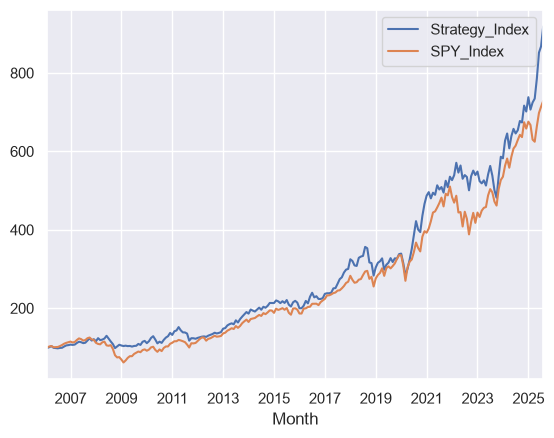

In [14]:
# Graph the Results
df_isolated_returns = backtest_results[['Strategy_Index', 'SPY_Index']].copy()
df_isolated_returns.plot()

## Visualizing Strategy Holdings with a Heatmap

While the performance chart shows us the "what" (our strategy's return), it does not show us the "how" or "why". To understand our strategy's behavior, we need to see which assets it was actually choosing to hold each month. Did it stick with the same winners for long periods? Did it rotate between asset classes?

A heatmap is the perfect visualization for this task. It will create a grid where each row is an ETF and each column is a month. We can then color the cells to show which ETFs were in our top 10 portfolio at any given time. This function, `plot_holdings_heatmap`, is designed to generate this powerful visualization.

**Function Breakdown**

This function is more complex than our previous ones, so let us break it down into logical steps.

1. Convert Picks to a Weights DataFrame: The function's input is our `top_etfs` Series, which just contains a list of tickers for each month. The first step is to convert this into a structured DataFrame where rows are dates, columns are all possible tickers in our universe, and the cell values represent the portfolio weight. Since our strategy is equal-weighted, if an ETF is in the top 10, its weight is 1/10 (or 0.1); otherwise, its weight is 0.

2. Transpose for Plotting: Heatmaps are typically easier to read when the time axis is horizontal (x-axis) and the categories (our ETFs) are vertical (y-axis). The line `plot_data = weights_df.T` transposes the DataFrame to get it into this standard format. The 'T' stands for transpose.

3. Handle Annotations: The function has an option, `annotate_weights`, to either show the percentage weight in each cell or just show a colored box indicating presence. This if/else block prepares the annotations accordingly. For this notebook, we will just show presence (1 or 0).Note that when dealing with this many ETFs the annotations will get messy! I wouldn't use them, but I am giving you the flexibility.

4. Create the Plot: This section uses the seaborn library to create the heatmap.

  - `sns.heatmap(...)`: This is the main function call.

  - `cmap='Blues'`: This sets the color scheme. It will color cells with a value of 1 in blue and cells with a value of 0 in white.

  - `cbar=False`: This removes the color bar legend, as it is not needed for a simple presence chart.

  - `annot=annot`: This tells seaborn to write the text (either the weights or nothing) inside each cell.

5. Format Axis Ticks: The final section is dedicated to making the x-axis (the dates) readable. Because we have many months, the default labels would overlap and be unreadable. This code manually sets a tick for every single month and rotates the labels 90 degrees so they are displayed vertically, ensuring every rebalancing date is clearly visible.

Now, let us call this function to see our strategy's history.

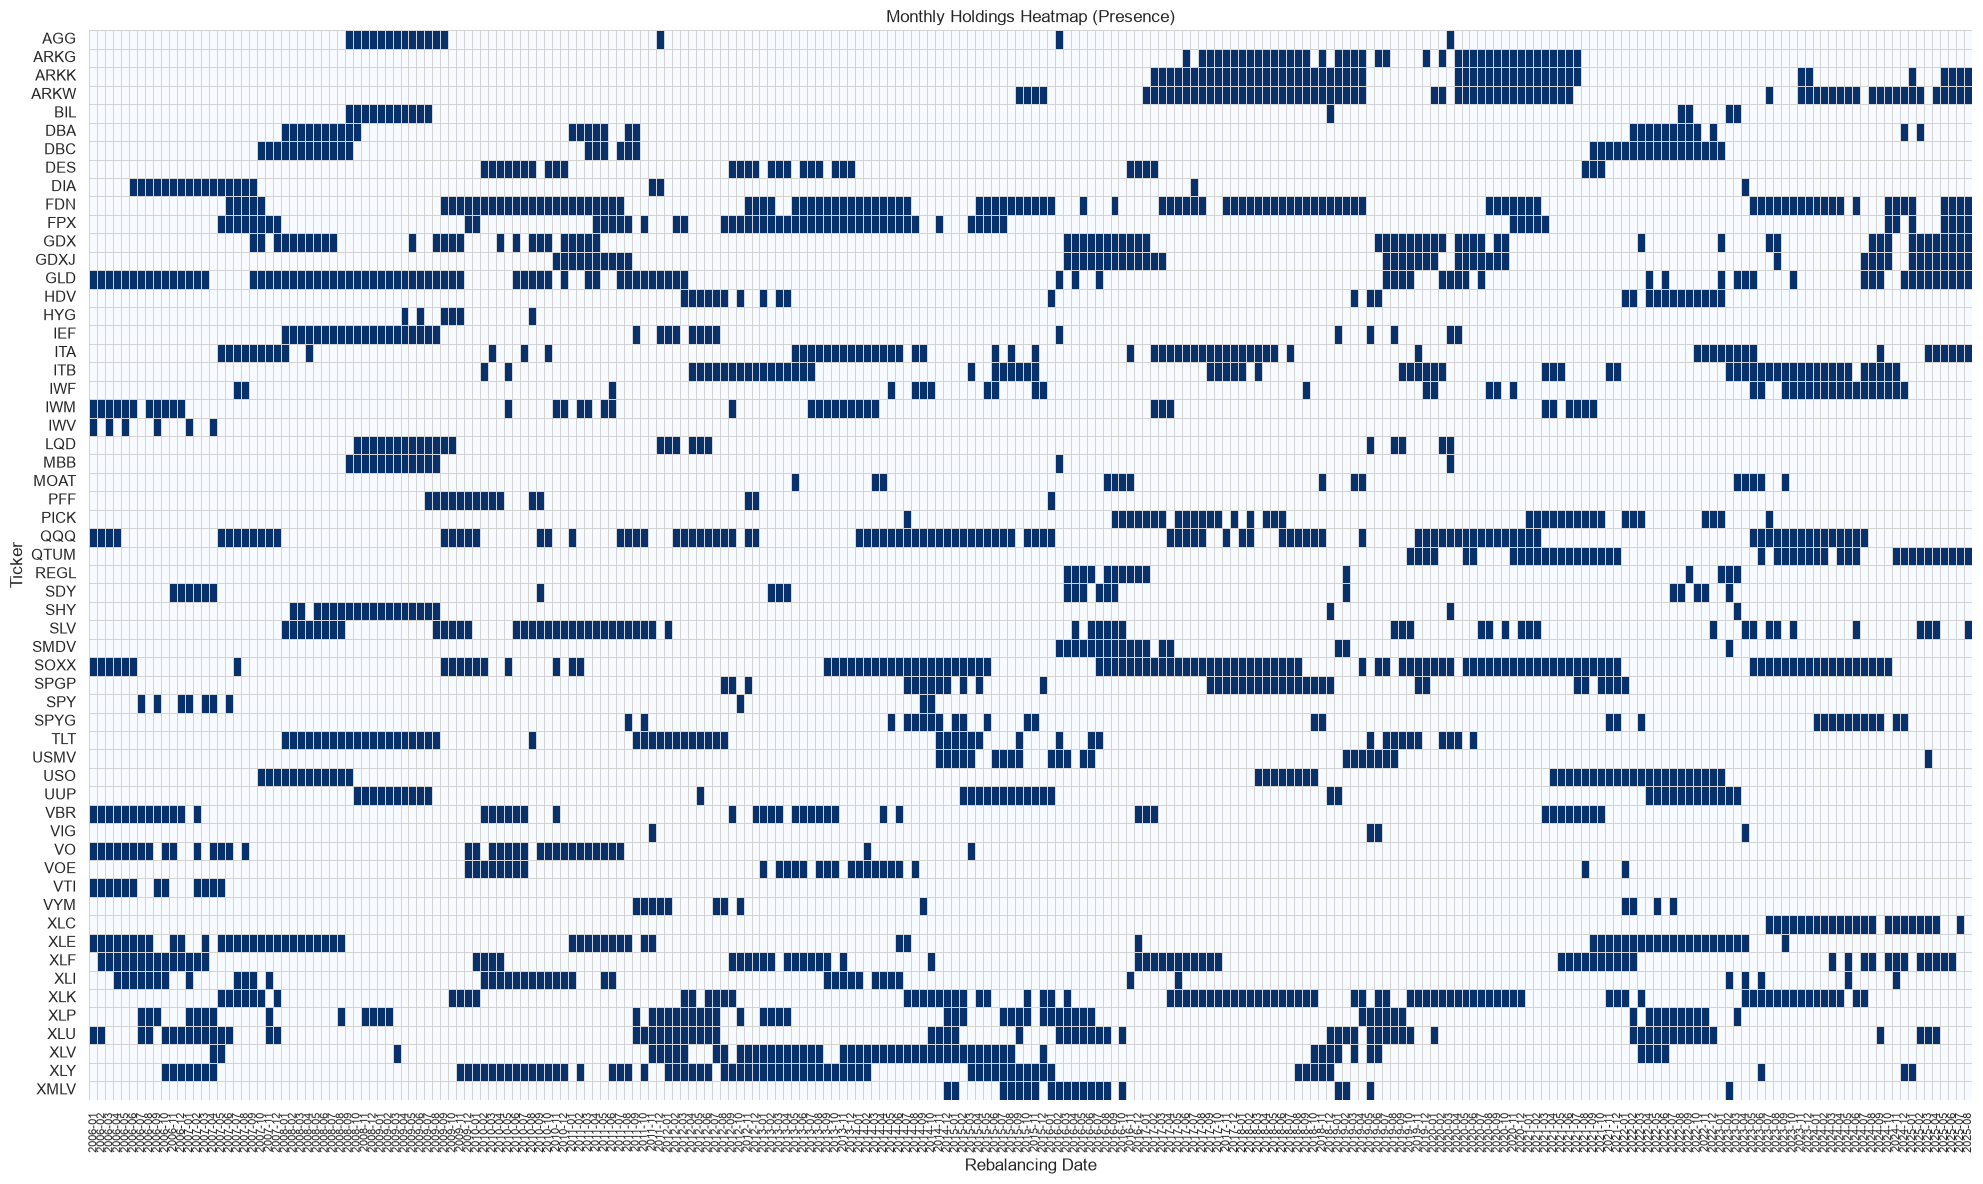

In [15]:
# Visualize holdings over time
def plot_holdings_heatmap(
    monthly_picks_s: pd.Series,
    figsize: tuple = (20, 12),
    annotate_weights: bool = False
):
    """
    Plots a heatmap of monthly holdings based on a Series of ticker picks.
    """
    # 1. Convert the Series of picks into a monthly weights DataFrame
    all_tickers = sorted(list(set(ticker for picks in monthly_picks_s for ticker in picks)))
    weights_df = pd.DataFrame(0.0, index=monthly_picks_s.index, columns=all_tickers)
    for date, tickers in monthly_picks_s.items():
        if tickers:
            weights_df.loc[date, tickers] = 1 / len(tickers)

    # 2. Transpose the DataFrame for plotting
    plot_data = weights_df.T

    # 3. Generate annotations
    if annotate_weights:
        annot = plot_data.applymap(lambda x: f"{int(round(x * 100))}" if x > 0 else "")
        heatmap_data = plot_data
    else:
        annot = None
        heatmap_data = (plot_data > 0).astype(int)

    # 4. Create the plot
    plt.figure(figsize=figsize)
    ax = sns.heatmap(
        heatmap_data,
        cmap='Blues',
        cbar=False,
        linewidths=0.5,
        linecolor='lightgray',
        annot=annot,
        fmt='',
        annot_kws={"size": 8, "color": "black"}
    )

    plt.xlabel("Rebalancing Date")
    plt.ylabel("Ticker")
    plt.title("Monthly Holdings Heatmap" + (" (Weight %)" if annotate_weights else " (Presence)"))

    # --- Corrected X-axis Tick Formatting (Shows EVERY month) ---
    # Set a tick position for every single column (month)
    ax.set_xticks(np.arange(len(plot_data.columns)) + 0.5)
    # Set the labels for every tick, rotated vertically
    ax.set_xticklabels([d.strftime('%Y-%m') for d in plot_data.columns], rotation=90)

    plt.yticks(rotation=0)
    # Adjust font size to make labels smaller and more likely to fit
    plt.tick_params(axis='x', labelsize=8)
    plt.tight_layout()
    plt.show()


plot_holdings_heatmap(top_etfs, annotate_weights=False)

## Export Needed Data
That's it!
However, and this is a big however. The backtest we jsut did is not sophistictaed and actually does not do a good job at all:

1. The backtest assumes you get the actually daily return for each ETF which is not the case. In reality, we generate the signals at month-end, and we need to trade the next business day. This means we trade at the open price. The current backtest assumes we trade at the closing price which isn't possible.

2. The simple backtest ignores:
    - Commissions and trading costs.
    - Slippage (the price we actually trade at depends on quantitiy traded and the actual bid-ask spreads).
    - The amount of shares owned (we can't buy fractional shares, so we need to round down and keep a running cash balance).

Because of these major issues, we will build a professional and complete backtest in the next notebook.

To avoid having to do our calculations again, we will store needed data as pickle files, which will be stored in this notebook instance.

**REMEMBER TO DOWNLOAD THEM FROM THE FILE EXPLORER IN THE LEFT SIDE PANEL. IF YOU CLOSE THE NOTEBOOK, YOU WILL LOSE THESE FILES!**

In [16]:
# Export the daily prices and top_etfs for use in a real backtest
top_etfs.to_pickle('top_etfs_monthly.pkl')

print("Monthly ETF picks saved to 'top_etfs_monthly.pkl'")

df_ranks.to_pickle('etf_monthly_rankings.pkl')
print("Monthly ETF ranks saved to 'etf_monthly_rankings.pkl'")

Monthly ETF picks saved to 'top_etfs_monthly.pkl'
Monthly ETF ranks saved to 'etf_monthly_rankings.pkl'


In [17]:
# To store all needed prices for the backtest, we need to keep open and close prices.
# Use this code to download and store all prices

all_ohlc_dfs = []
print(f"Fetching OHLC data for {len(tickers)} tickers one by one...")

for ticker in tickers:
    print(f"  Fetching {ticker}...")
    # Fetch data for one ticker using your existing function
    try:
        single_df = fn.get_stock_prices(ticker, start_date, end_date, fmp_api_key=fmp_api_key)

        if not single_df.empty:
            # Add the ticker as the top level for the columns to create a MultiIndex
            single_df.columns = pd.MultiIndex.from_product([[ticker], single_df.columns])
            all_ohlc_dfs.append(single_df)
        else:
            print(f"    -> No data returned for {ticker}")
    except Exception as e:
        print(f"    -> An error occurred for {ticker}: {e}")


if all_ohlc_dfs:
    # Combine all the individual DataFrames into one
    prices_daily_df = pd.concat(all_ohlc_dfs, axis=1)

    # Save the result to pickle
    prices_daily_df.to_pickle('df_prices_daily.pkl')

    print("\nDaily pricing data saved to 'df_prices_daily.pkl'")
    print("Data starts on:", prices_daily_df.index.min().strftime('%Y-%m-%d'))
    print("Data ends on:", prices_daily_df.index.max().strftime('%Y-%m-%d'))
    # Display the head to verify the date range
    display(prices_daily_df.head())
else:
    print("\nNo data was fetched. The final DataFrame is empty.")

Fetching OHLC data for 58 tickers one by one...
  Fetching QQQ...
Data retrieved from Yahoo Finance for QQQ
  Fetching VTI...
Data retrieved from Yahoo Finance for VTI
  Fetching VYM...
Data retrieved from Yahoo Finance for VYM
  Fetching IWM...
Data retrieved from Yahoo Finance for IWM
  Fetching SMDV...
Data retrieved from Yahoo Finance for SMDV
  Fetching SPYG...
Data retrieved from Yahoo Finance for SPYG
  Fetching IWF...
Data retrieved from Yahoo Finance for IWF
  Fetching VO...
Data retrieved from Yahoo Finance for VO
  Fetching VBR...
Data retrieved from Yahoo Finance for VBR
  Fetching VOE...
Data retrieved from Yahoo Finance for VOE
  Fetching SPGP...
Data retrieved from Yahoo Finance for SPGP
  Fetching REGL...
Data retrieved from Yahoo Finance for REGL
  Fetching IWV...
Data retrieved from Yahoo Finance for IWV
  Fetching XLF...
Data retrieved from Yahoo Finance for XLF
  Fetching XLE...
Data retrieved from Yahoo Finance for XLE
  Fetching XLK...
Data retrieved from Yahoo Fi

QQQ                                                         \
Price       Adj Close      Close       High        Low       Open     Volume   
Date                                                                           
2005-01-03  33.615986  39.500000  40.290001  39.369999  40.090000  100970900   
2005-01-04  33.003258  38.779999  39.740002  38.549999  39.669998  136623200   
2005-01-05  32.799030  38.540001  38.959999  38.470001  38.680000  127925500   
2005-01-06  32.637314  38.349998  38.709999  38.340000  38.630001  102934600   
2005-01-07  32.807522  38.549999  38.869999  38.209999  38.560001  123104000   

                  VTI                                   ... GDXJ           \
Price       Adj Close      Close       High        Low  ... High Low Open   
Date                                                    ...                 
2005-01-03  39.853489  58.599998  59.424999  58.450001  ...  NaN NaN  NaN   
2005-01-04  39.323025  57.820000  58.750000  57.639999  ...  NaN NaN  NaN   
2005-01-05  39.050983  57.419998  57.974998  57.419998  ...  NaN NaN  NaN   
2005-01-06  39.238007  57.695000  57.895000  57.430000  ...  NaN NaN  NaN   
2005-01-07  39.112179  57.509998  57.825001  57.355000  ...  NaN NaN  NaN   

                        DBA                             
Price      Volume Adj Close Close High Low Open Volume  
Date                                                    
2005-01-03    NaN       NaN   NaN  NaN NaN  NaN    NaN  
2005-01-04    NaN       NaN   NaN  NaN NaN  NaN    NaN  
2005-01-05    NaN       NaN   NaN  NaN NaN  NaN    NaN  
2005-01-06    NaN       NaN   NaN  NaN NaN  NaN    NaN  
2005-01-07    NaN       NaN   NaN  NaN NaN  NaN    NaN  

[5 rows x 348 columns]

REMEMBER TO DOWNLOAD ALL FILES FROM THE FILE SECTION!

You will need to import them for the backtest notebook.
These files can also be found in the Resources section of the next part of the course to ensure we all work with the same data.

## Disclaimers

**Please Read Carefully**
- For Educational Purposes Only: The content in this course, including all code, strategies, and analysis, is provided for educational and informational purposes only.
- Not Investment Advice: The information presented is not, and should not be construed as, investment advice, financial advice, trading advice, or a recommendation to buy or sell any security. All investment decisions are your own.
- No Guarantees & Past Performance: Trading and investing involve substantial risk. Past performance, whether actual or indicated by historical tests of strategies, is no guarantee of future results. There is no guarantee that any strategy presented here will be profitable.
- Assumption of Risk: You, and you alone, are solely responsible for any investment decisions you make and for any and all losses that may result from them. The instructor and Digital Hub Insights LLC will not be held responsible for any investment losses you may incur.
- Consult a Professional: Always consult with a licensed financial advisor and/or tax professional to determine the suitability of any investment.



---
## Liquidity Filter: Wiring It Into the Real Signal

`get_top_etfs` above can select ETFs that are too thin to trade at real size. This cell fetches
daily volume (not returned by `get_bulk_prices`, only by the single-symbol `get_stock_prices`),
builds a dollar-volume panel, and applies `liquidity_filter()` from `functions_quant_extensions.py`
before ranking, so `top_etfs` only ever contains names that clear a minimum tradability bar.


In [18]:
from momentum_trading.core import functions_quant_extensions as fnx

# Fetch volume per ticker (get_bulk_prices doesn't return it, so we go one at a time
# via get_stock_prices, which does). This uses the SAME auto-fallback source chain,
# so it stays consistent with how df_prices was built.
volume_frames = {}
for t in tickers:
    try:
        raw = fn.get_stock_prices(t, start_date, end_date, fmp_api_key=fmp_api_key, eodhd_api_key=eodhd_api_key)
        vol_col = next((c for c in raw.columns if c.lower() == 'volume'), None)
        if vol_col:
            volume_frames[t] = raw[vol_col]
    except Exception as e:
        print(f"Skipping volume for {t}: {e}")

df_volume = pd.DataFrame(volume_frames)

# Apply the liquidity filter BEFORE selecting top_n, at $1M min trailing avg dollar volume
df_ranks_liquid = fnx.liquidity_filter(
    df_ranks, df_prices_monthly, df_volume=df_volume,
    min_avg_dollar_volume=1_000_000.0, lookback_days=63,
)

top_etfs_liquid = get_top_etfs(df_ranks_liquid, top_n=10)

# Sanity check: how often did the liquidity filter actually change the pick list?
changed = sum(1 for d in top_etfs.index if set(top_etfs.get(d, [])) != set(top_etfs_liquid.get(d, [])))
print(f"Liquidity filter changed the pick list in {changed} / {len(top_etfs)} months.")
top_etfs_liquid.head()


Data retrieved from Yahoo Finance for QQQ
Data retrieved from Yahoo Finance for VTI
Data retrieved from Yahoo Finance for VYM
Data retrieved from Yahoo Finance for IWM
Data retrieved from Yahoo Finance for SMDV
Data retrieved from Yahoo Finance for SPYG
Data retrieved from Yahoo Finance for IWF
Data retrieved from Yahoo Finance for VO
Data retrieved from Yahoo Finance for VBR
Data retrieved from Yahoo Finance for VOE
Data retrieved from Yahoo Finance for SPGP
Data retrieved from Yahoo Finance for REGL
Data retrieved from Yahoo Finance for IWV
Data retrieved from Yahoo Finance for XLF
Data retrieved from Yahoo Finance for XLE
Data retrieved from Yahoo Finance for XLK
Data retrieved from Yahoo Finance for XLV
Data retrieved from Yahoo Finance for XLY
Data retrieved from Yahoo Finance for XLI
Data retrieved from Yahoo Finance for XLP
Data retrieved from Yahoo Finance for XLU
Data retrieved from Yahoo Finance for XLC
Data retrieved from Yahoo Finance for SOXX
Data retrieved from Yahoo Fina

date
2006-01-31    [QQQ, VTI, VYM, IWM, SMDV, SPYG, IWF, VO, VBR,...
2006-02-28    [QQQ, VTI, VYM, IWM, SMDV, SPYG, IWF, VO, VBR,...
2006-03-31    [QQQ, VTI, VYM, IWM, SMDV, SPYG, IWF, VO, VBR,...
2006-04-30    [QQQ, VTI, VYM, IWM, SMDV, SPYG, IWF, VO, VBR,...
2006-05-31    [QQQ, VTI, VYM, IWM, SMDV, SPYG, IWF, VO, VBR,...
Freq: ME, dtype: object